In [ ]:
## 0. load packages
import os, sys
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import matplotlib.ticker as ticker
from datetime import datetime
from matplotlib.lines import Line2D
from scipy.stats import theilslopes

if 'wsl' in os.uname().release.lower():
    os.chdir('/mnt/h/CROP/')
    sys.path.insert(0, '/mnt/h/CROP/')
else:
    os.chdir('/h/u145/liuxinrui/CROP/')
    sys.path.insert(0, '/h/u145/liuxinrui/CROP/')

nMC = 1000
out_dir = 'results/Mar/'

run_yr = (1960, 2021)
spcs4 = ['mai', 'ric', 'soy', 'whe']
crop_mapping = {'Maize': ['mai'], 'Rice':['ri1', 'ri2', 'ric'], 'Soybean':['soy'], 'Wheat':['swh', 'wwh', 'whe']}

## dry weight conversion factor
## https://doi.org/10.5194/essd-17-369-2025, Table 2
dw = xr.DataArray([0.82, 0.87, 0.85, 0.86], coords={'spc_crop': ['mai', 'ric', 'soy', 'whe']}, dims=['spc_crop'])

!!! Attention: only keep the nitrogen module


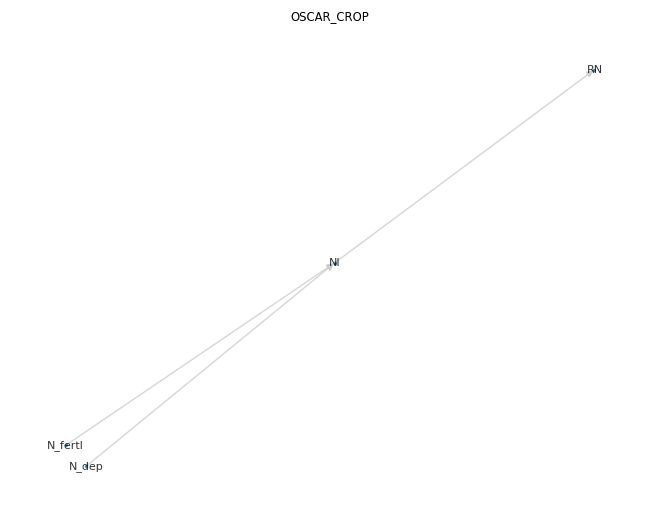

In [ ]:
## 1. make model

from core.OSCAR_crop import CROP

use_MIT = True
use_Geo = False
use_2nd = False
use_MM = False

CROP = CROP(option='offline', use_MIT=use_MIT, use_Geo=use_Geo, use_2nd=use_2nd, use_MM=use_MM)
print('!!! Attention: only keep the nitrogen module')
proc_del = [proc for proc in CROP._processes.values() if proc.Out not in ['RN', 'NI']]
for proc in proc_del:
    CROP.__delitem__(proc.Out)

func_2nd = lambda x, a, b: a*x**2+b*x
## Michaelis-Menten function
func_MM = lambda x, a, b: a*x/(x+b)
## Mitcherlich function
func_Mit = lambda x, a, b: a*np.expm1(b*x)
## George function
func_Geo = lambda x, a, b: a*(np.power(0.99, x)-1)+b*x

if use_MIT: func_RN = func_Mit
if use_Geo: func_RN = func_Geo
if use_2nd: func_RN = func_2nd
if use_MM: func_RN = func_MM

CROP.process(
    Out = 'RN', 
    In = ('NI', ),
    Eq = lambda Var, Par: Eq__RN(Var, Par),
    units='1',
    core_dims=['spc_crop']
)

def Eq__RN(Var, Par):
    NI_0 = Par.N_fertl_0 + Par.N_dep_0 + Par.N_bnf
    RN = func_RN(Var.NI / 100, Par.g_a, Par.g_b) / func_RN(NI_0 / 100, Par.g_a, Par.g_b)
    RN = RN.where(RN > 0)
    return RN

CROP.display()

In [ ]:
## 2. load nitrogen parameters for soybean

Par = xr.load_dataset(f'{out_dir}historical/Par_hist.nc')
for var in ['g_a', 'g_b']:
    Par[var].loc[{'spc_crop': 'soy'}] = Par[var].sel(spc_crop='wwh').values
Par = Par.sel(spc_crop='soy')
print(Par)

# from core.Par_crop import load_nitro_param

# Par = load_nitro_param()
# Par['N_bnf'] = Par['N_bnf'].sel(mod_bnf_soy='Ma_2022').squeeze()
# Par = Par.drop_dims(['mod_bnf_soy'])

# from core.fct_genMC import generate_config
# Par = generate_config(Par, nMC=nMC)

<xarray.Dataset> Size: 80MB
Dimensions:       (config: 1000, reg_code: 311, irr: 2, data_N_fertl: 2)
Coordinates:
  * config        (config) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
    spc_crop      <U3 12B 'soy'
  * reg_code      (reg_code) <U5 6kB 'XXX' 'ABW' 'AFG' ... 'ZAF' 'ZMB' 'ZWE'
    reg_name      (reg_code) <U44 55kB 'Unknown' 'Aruba' ... 'Zambia' 'Zimbabwe'
  * irr           (irr) <U5 40B 'firr' 'noirr'
  * data_N_fertl  (data_N_fertl) <U14 112B 'Jagermeyr_2021' 'LUH2-v2h'
Data variables: (12/25)
    g_a           (config) float64 8kB -1.076 -1.021 -1.025 ... -1.043 -1.063
    g_b           (config) float64 8kB -1.283 -1.196 -1.251 ... -1.356 -1.186
    w_Tl          (reg_code, config) float64 2MB nan nan nan ... 1.647 1.144
    w_Tgs         (reg_code, irr, config) float64 5MB nan nan ... 0.8892 1.037
    w_Pl          (reg_code, config) float64 2MB nan nan nan ... 0.6796 0.6933
    w_Pgs         (reg_code, irr, config) float64 5MB nan nan ... -0.02934
    ...  

In [12]:
## 3. load nitrogen input for soybean

For = xr.load_dataset(f'{out_dir}historical/For_hist.nc')[['N_fertl', 'N_dep']].sel(spc_crop='soy')

print(For)

<xarray.Dataset> Size: 524kB
Dimensions:       (year: 62, reg_code: 311, data_N_fertl: 2)
Coordinates:
  * year          (year) int32 248B 1960 1961 1962 1963 ... 2018 2019 2020 2021
  * reg_code      (reg_code) <U5 6kB 'XXX' 'ABW' 'AFG' ... 'ZAF' 'ZMB' 'ZWE'
    reg_name      (reg_code) <U44 55kB 'Unknown' 'Aruba' ... 'Zambia' 'Zimbabwe'
    spc_crop      <U3 12B 'soy'
  * data_N_fertl  (data_N_fertl) <U14 112B 'Jagermeyr_2021' 'LUH2-v2h'
    data_N_dep    <U8 32B 'ISIMIP3b'
Data variables:
    N_fertl       (year, reg_code, data_N_fertl) float64 309kB nan nan ... 18.11
    N_dep         (year, reg_code) float64 154kB 0.0 0.6249 2.396 ... 0.0 0.0


In [13]:
## 4. output parameters

Par['N_fertl_0'] = For['N_fertl'].sel(year=2015, drop=True)
# Par.to_netcdf('{out_dir}Par_nitro.nc')

In [14]:
## 5. run simulations

Out_nitro = CROP(Ini=None, Par=Par, For=For, var_keep=['NI', 'RN'])
Out_nitro.attrs['description'] = 'Historical nitrogen input and response for soybean, assuming same response coefficients as wheat'

Out_nitro.to_netcdf(f'{out_dir}hist_nitro_soy.nc')

print(Out_nitro)

OSCAR_CROP running
year = 1961 WARNING: cannot adapt nt as D_CO2 is not a variable or driver
year = 2021 (nt = 2)(nt = 2)
total running time: 0.1 minutes
<xarray.Dataset> Size: 309MB
Dimensions:       (year: 62, reg_code: 311, data_N_fertl: 2, config: 1000)
Coordinates:
  * reg_code      (reg_code) <U5 6kB 'XXX' 'ABW' 'AFG' ... 'ZAF' 'ZMB' 'ZWE'
    reg_name      (reg_code) <U44 55kB 'Unknown' 'Aruba' ... 'Zambia' 'Zimbabwe'
    spc_crop      <U3 12B 'soy'
  * data_N_fertl  (data_N_fertl) <U14 112B 'Jagermeyr_2021' 'LUH2-v2h'
    data_N_dep    <U8 32B 'ISIMIP3b'
  * config        (config) int64 8kB 0 1 2 3 4 5 6 ... 994 995 996 997 998 999
  * year          (year) int32 248B 1960 1961 1962 1963 ... 2018 2019 2020 2021
Data variables:
    NI            (year, reg_code, data_N_fertl) float64 309kB nan nan ... 190.1
    RN            (year, config, reg_code, data_N_fertl) float64 309MB nan .....
Attributes:
    model:        OSCAR_CROP
    description:  Historical nitrogen input and respo

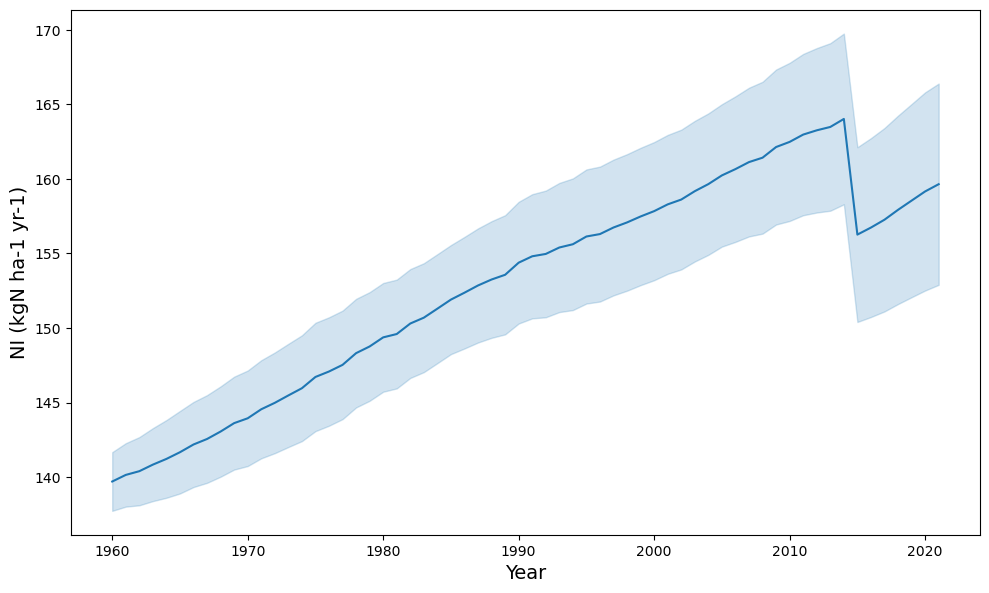

In [ ]:
## 6. load results and check

from core.utils_crop import load_cropland_weights
wgt = load_cropland_weights().sel(spc_crop='soy', drop=True)

varname = 'NI'
try:
    var = Out_nitro[varname].weighted(wgt).mean('reg_code', keep_attrs=True)
except:
    var = xr.load_dataset(f'{out_dir}hist_nitro_soy.nc')[varname].weighted(wgt).mean('reg_code', keep_attrs=True)

fig, ax = plt.subplots(figsize=(10, 6))

errorbar = ('sd', 1)
df_hist = var.to_dataframe()
sns.lineplot(data=df_hist, x='year', y=varname, errorbar=errorbar, ax=ax)

plt.xlabel('Year', fontsize=14)
plt.ylabel(f'{varname} ({var.units})', fontsize=14)
plt.tight_layout()
plt.subplots_adjust(bottom=0.1)
plt.show()

++++++++++++++++++++++++++++++++++++++++++++++++++
Current date and time: 2026-03-19 14:20:36.905965
++++++++++++++++++++++++++++++++++++++++++++++++++ 

Average dimensions over ['data_clim', 'data_N_fertl', 'data_Ac', 'data_Ah']
The following datasets are not compatible: ['Adalibieke_2023', 'CROPGRIDSv1.07', 'RiceAtlas', 'FAO']
Loading 5 datasets for sub-national region
Loading harvested-area__Waha_2020_sub-national ...
Loading harvested-area__Becker-Reshef_2023_sub-national ...
Loading harvested-area__MIRCA2000_sub-national ...
Loading harvested-area__Monfreda_2008_sub-national ...
Loading harvested-area__ric-ISIMIP3b_sub-national ...
Harvested area data does not have a year dimension, checking the last year...
Region mapping file for old region "Sub-national" and new region "National" in input_data/regions/.
Region mapping file for old region "National" and new region "Soybean" in input_data/regions/.
<xarray.Dataset> Size: 119MB
Dimensions:       (year: 62, reg_code: 6, data_Ah: 5,

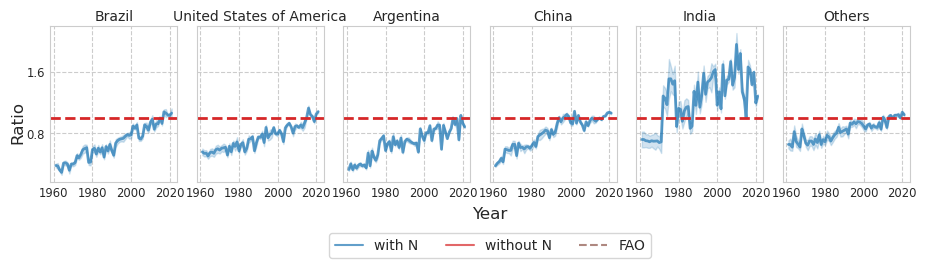

In [ ]:
## 7. compare the trend between FAO and non-nitrogen input scenarios

print('+'*50)
current_datetime = datetime.now()
print(f'Current date and time: {current_datetime}')
print('+'*50, '\n')

from core.utils_crop import aggreg_region

spc = 'soy'
fn = f'{out_dir}historical/CY4_all.nc'
var = xr.load_dataarray(fn).sel(year=slice(*run_yr)).squeeze().sel(spc_crop=spc)

dim_avg = [dim for dim in var.dims if dim not in ['spc_crop', 'year', 'reg_code', 'config'] ]
if len(dim_avg) != 0:
    print(f'Average dimensions over {dim_avg}')
    var = var.mean(dim_avg, skipna=True).squeeze()

## FAO reports yield in fresh weight
source = 'FAO'
yd_obs = xr.load_dataarray(f'input_data/observations/yield__{source}_national.nc').sel(year=slice(*run_yr)).sel(spc_crop=spc)
yd_obs = yd_obs.sel(reg_code=var.reg_code) * dw.sel(spc_crop=spc)
yd_obs = yd_obs.rename('YD_in')

from core.Dri_crop import load_harvested_hist
Ah = load_harvested_hist(crop_species=[spc], mod_region='sub-national').squeeze()['Ah']
if 'year' not in Ah.dims:
    print('Harvested area data does not have a year dimension, checking the last year...')
else:
    assert Ah.year[-1] >= run_yr[-1], f'Harvested area data ends at {Ah.year[-1]}, but simulation runs until {run_yr[-1]}'
    Ah = Ah.sel(year=slice(*run_yr)).rename({'data_Ah': 'weight_Ah'})

ds_obs = xr.merge([Ah, NI]).dropna(dim='year', how='all')
ds_obs = aggreg_region(ds_obs, new_region='National', weight_dict={'NI': 'Ah'}, time_axis='year')
ds_obs = ds_obs.rename({'reg_code_new': 'reg_code'})

## only use data (in terms of both region and time) available in both datasets
MATCH = True
if MATCH:
    cond = (var > 0) & (yd_obs > 0) & (ds_obs['Ah'] > 0) & (ds_obs['NI'] > 0)
    ds_obs['YD'] = var.where(cond).rename('YD')
    ds_obs['YD_in'] = yd_obs.where(cond).rename('YD_in')
    ds_obs['Ah'] = ds_obs['Ah'].where(cond).rename('Ah')

AGG = True
if AGG:
    Var0 = []
    Var_mod = ds_obs.rename({'reg_code': 'reg_code_new'})
    spc_type = next((key for key, val in crop_mapping.items() if spc in val), None)
    if spc_type is None: raise ValueError(f'Crop {spc} not found in crop mapping.')
    Var_mod = aggreg_region(
        Var_mod, old_region='National', new_region=spc_type, 
        weight_dict={f'YD': 'Ah', 'YD_in': 'Ah', 'NI': 'Ah'}, 
        old_axis='reg_code_new', new_axis='reg_code', time_axis='year'
    )
print(Var_mod)

## TODO: check the trend of NI, yd_obs, yd
## standardize the yield
Var_mod['YD'] = Var_mod['YD'] / Var_mod['YD'].sel(year=2015, drop=True)
Var_mod['YD_in'] = Var_mod['YD_in'] / Var_mod['YD_in'].sel(year=2015, drop=True)
Var_mod['NI'] = Var_mod['NI'] / Var_mod['NI'].sel(year=2015, drop=True)
Var_mod['ratio'] = Var_mod['YD_in'] / Var_mod['YD']
print(Var_mod['ratio'])

from core.utils_crop import calc_rrmse
errorbar = ('sd', 1)
fig, axs = plt.subplots(1, 6, figsize=(10, 2), **{'sharex':True, 'sharey': True})
spc_type = next((key for key, val in crop_mapping.items() if spc in val), None)
if spc_type is None: raise ValueError(f'Crop {spc} not found in crop mapping.')
for r in range(6):
    ax = axs[r]
    ax.tick_params(axis='both', direction='in')
    ax.xaxis.set_tick_params(labelsize='small')
    ax.yaxis.set_tick_params(labelsize='small')
    ax.xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    ax.xaxis.set_major_locator(ticker.MaxNLocator(4))
    ax.yaxis.set_major_formatter(ticker.FormatStrFormatter('%.1f'))
    ax.yaxis.set_major_locator(ticker.MaxNLocator(3))

    df_reg = Var_mod.sel(reg_code=f'{spc.upper()}{r+1}').to_dataframe()
    rrmse = calc_rrmse(df_reg['ratio'].values, df_reg['YD_in'].values)[0] * 100
    print(f'{spc.upper()}{r+1} | RRMSE: {rrmse:.2f}%')
    sns.lineplot(
        data=df_reg,
        x='year',
        y=f'ratio',
        c='tab:blue',
        alpha=0.7,
        lw=2,
        ax=ax,
        errorbar=errorbar
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.axhline(1, c='tab:red', ls='--', lw=2)
    ax.set_title(
        f'{Var_mod[f'{spc_type}_name'].sel(reg_code=f'{spc.upper()}{r+1}').values}', 
        y=0.98, 
        fontsize='medium'
    )
    ax.grid(True, linestyle='--')

fig.supxlabel(r'Year', y=0.00)
fig.supylabel(f'Ratio', x=0.02) 

legend = [ Line2D([0, 1], [0, 1], alpha=0.7, c=color, ls='-', label=rf'{label}')
            for color, label in [('tab:blue', 'with N'), ('tab:red', 'without N')]
        ] + [ Line2D([0, 1], [0, 1], alpha=0.7, c='tab:brown', ls='--', label=f'{source}')]
fig.legend(handles=legend, loc='upper center', ncol=4, bbox_to_anchor=(0.5, -0.02))
plt.subplots_adjust(left=0.06, bottom=0.2, right=0.92, top=0.98, wspace=0.15, hspace=0.2)
# plt.savefig(f'results/historical/fao_{varname}.png')
plt.show()